# 2. Data Cleaning

Data cleaning prepares raw data for machine learning by fixing common quality issues.

In this notebook section covers:

1. Missing data detection and treatment  
2. Missing data patterns: MCAR, MAR, MNAR  
3. Outlier detection using IQR, Z-score, and Isolation Forest  
4. Outlier treatment using trimming, winsorization, and transformations  
5. Feature scaling using StandardScaler, MinMaxScaler, and RobustScaler  

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest

## Titanic Dataset

In [2]:

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


### Missing Data Detection

Missing data can be detected using:

- `.isnull()`
- `.isnull().sum()`
- Missing-value heatmaps

Missing data strategy depends on the pattern:

- **MCAR**: Missing Completely at Random
- **MAR**: Missing at Random
- **MNAR**: Missing Not at Random

If missingness itself contains signal, we can add a missing indicator column.

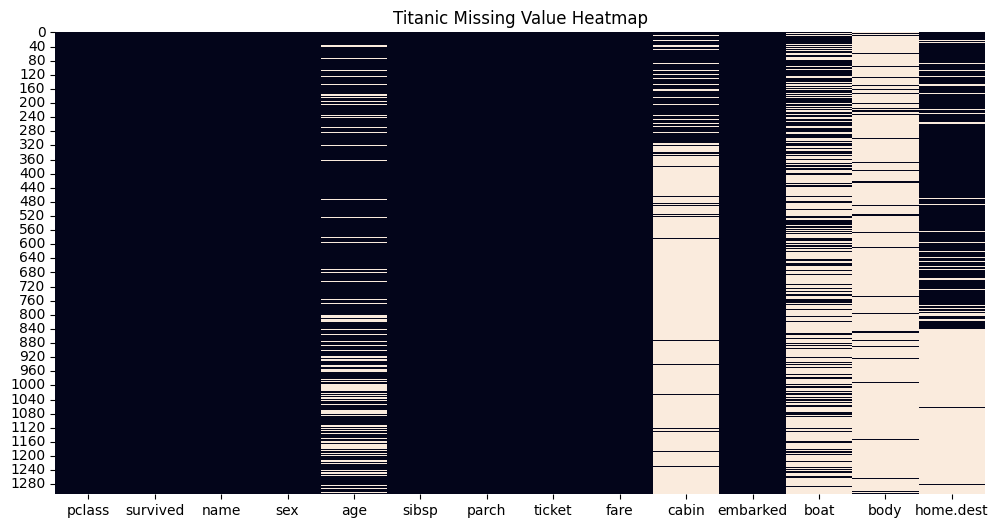

In [3]:
# Missing value heatmap for Titanic

plt.figure(figsize=(12, 6))
sns.heatmap(titanic_df.isnull(), cbar=False)
plt.title("Titanic Missing Value Heatmap")
plt.show()

### Missing Indicators

A missing indicator is a binary column showing whether a value was originally missing.

This is useful when missingness may carry information.  
For example, in Titanic, missing age may be related to passenger group, class, or survival.

,age,age_missing,survived
0,29.0000,0,1
1,0.9167,0,1
2,2.0000,0,0
3,30.0000,0,0
4,25.0000,0,0
5,48.0000,0,1
6,63.0000,0,1
7,39.0000,0,0
8,53.0000,0,1
9,71.0000,0,0


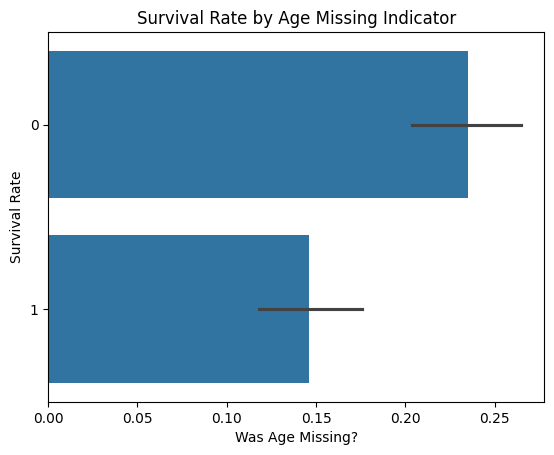

In [4]:
# Add missing indicator for Titanic age

titanic_df["age_missing"] = titanic_df["age"].isnull().astype(int)

display(titanic_df[["age", "age_missing", "survived"]].head(10))

sns.barplot(data=titanic_df, x="age_missing", y="survived")
plt.title("Survival Rate by Age Missing Indicator")
plt.xlabel("Was Age Missing?")
plt.ylabel("Survival Rate")
plt.show()

### Handling Missing Data

Common approaches:

1. **Remove rows or columns**
2. **Simple imputation**
3. **Advanced imputation**
4. **Model-based handling**


In [5]:
# Create a working copy

titanic_clean = titanic_df.copy()

# Numeric and categorical columns
numeric_cols = titanic_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = titanic_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'body', 'age_missing']
Categorical columns: ['survived', 'name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


C:\Users\samik\AppData\Local\Temp\ipykernel_3076\1165905746.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = titanic_clean.select_dtypes(include=["object", "category"]).columns.tolist()


In [6]:
# Simple imputation example

# Median imputation for numeric columns
num_imputer = SimpleImputer(strategy="median")
titanic_clean[numeric_cols] = num_imputer.fit_transform(titanic_clean[numeric_cols])

# Mode imputation for categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
titanic_clean[categorical_cols] = cat_imputer.fit_transform(titanic_clean[categorical_cols])

print("Missing values after imputation:")
display(titanic_clean.isnull().sum().sort_values(ascending=False).head(10))

Missing values after imputation:


pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
cabin       0
dtype: int64

### KNN Imputation

KNN imputation fills missing values using similar rows.

This can work well when nearby observations have similar feature values, but it is slower than simple imputation and is sensitive to scaling.

In [9]:
# KNN imputation example on selected Titanic numeric columns

knn_cols = ["age", "fare", "sibsp", "parch"]

titanic_knn = titanic_df[knn_cols].copy()

knn_imputer = KNNImputer(n_neighbors=5)
titanic_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(titanic_knn),
    columns=knn_cols
)
# Get indices of rows where age is missing
missing_age_indices = titanic_knn[titanic_knn['age'].isnull()].index

# Display original rows with missing age
display(titanic_knn.loc[missing_age_indices].head())

# Display imputed rows for the same indices
display(titanic_knn_imputed.loc[missing_age_indices].head())

,age,fare,sibsp,parch
15,NaN,25.9250,0,0
37,NaN,26.5500,0,0
40,NaN,39.6000,0,0
46,NaN,31.0000,0,0
59,NaN,27.7208,0,0


,age,fare,sibsp,parch
15,46.3,25.9250,0.0,0.0
37,49.9,26.5500,0.0,0.0
40,43.5,39.6000,0.0,0.0
46,48.3,31.0000,0.0,0.0
59,45.6,27.7208,0.0,0.0


### Outlier Detection

We will use:
1. Boxplots  
2. IQR method  
3. Z-score  
4. Isolation Forest  

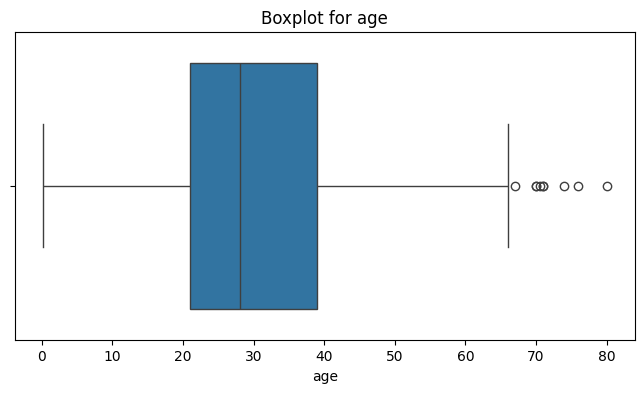

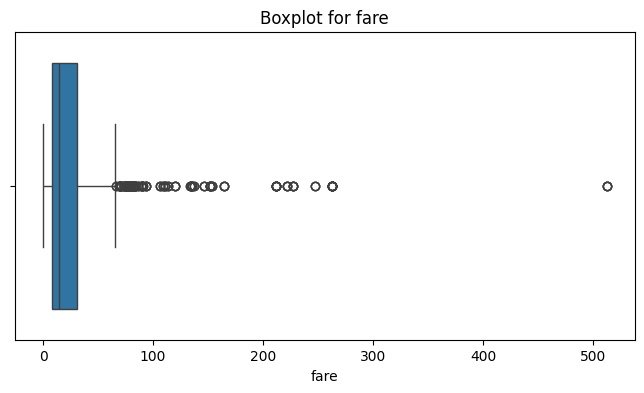

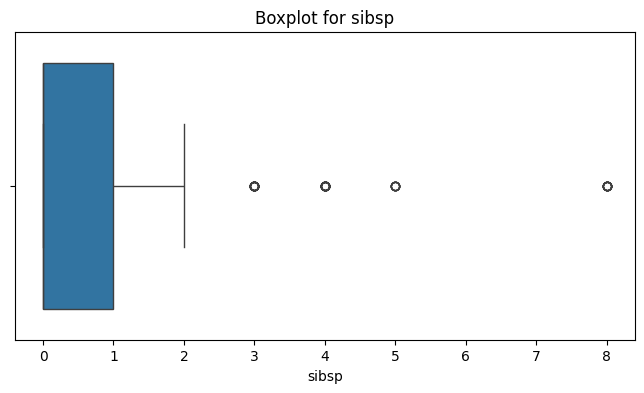

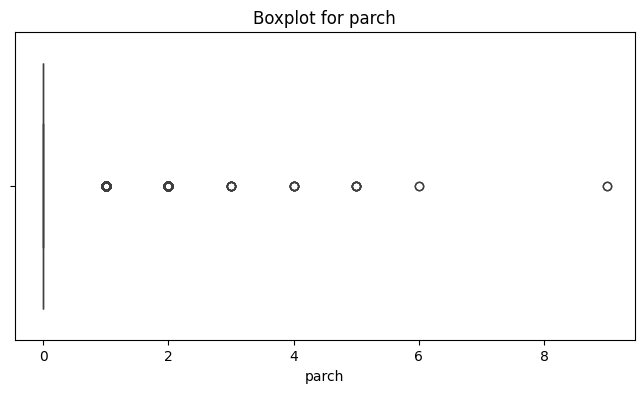

In [10]:
# Select numeric columns for Titanic

titanic_num = titanic_df[["age", "fare", "sibsp", "parch"]].copy()

for col in titanic_num.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=titanic_num[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [11]:
# IQR outlier detection function

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", outliers.shape[0])
    print("Percent outliers:", round(outliers.shape[0] / df.shape[0] * 100, 2), "%")
    
    return outliers

fare_outliers = detect_outliers_iqr(titanic_df, "fare")
display(fare_outliers[["fare", "pclass", "survived"]].head())

fare
Lower bound: -27.172999999999995
Upper bound: 66.34379999999999
Number of outliers: 171
Percent outliers: 13.06 %


,fare,pclass,survived
0,211.3375,1,1
1,151.5500,1,1
2,151.5500,1,0
3,151.5500,1,0
4,151.5500,1,0


In [12]:
# Z-score outlier detection

def detect_outliers_zscore(df, col, threshold=3):
    mean = df[col].mean()
    std = df[col].std()
    
    z_scores = (df[col] - mean) / std
    outliers = df[np.abs(z_scores) > threshold]
    
    print(f"{col}")
    print("Number of outliers:", outliers.shape[0])
    print("Percent outliers:", round(outliers.shape[0] / df.shape[0] * 100, 2), "%")
    
    return outliers

fare_z_outliers = detect_outliers_zscore(titanic_df.dropna(subset=["fare"]), "fare")
display(fare_z_outliers[["fare", "pclass", "survived"]].head())

fare
Number of outliers: 38
Percent outliers: 2.91 %


,fare,pclass,survived
0,211.3375,1,1
10,227.5250,1,0
11,227.5250,1,1
16,247.5208,1,0
17,247.5208,1,1


is_outlier
False    1243
True       66
Name: count, dtype: int64

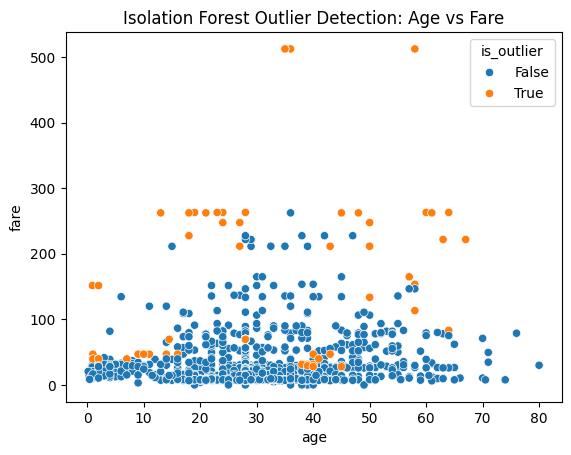

In [13]:
# Isolation Forest outlier detection

iso_cols = ["age", "fare", "sibsp", "parch"]

iso_df = titanic_df[iso_cols].copy()
iso_df = iso_df.fillna(iso_df.median())

iso = IsolationForest(contamination=0.05, random_state=42)
iso_df["outlier_flag"] = iso.fit_predict(iso_df)

# -1 means outlier, 1 means normal
iso_df["is_outlier"] = iso_df["outlier_flag"] == -1

display(iso_df["is_outlier"].value_counts())

sns.scatterplot(data=iso_df, x="age", y="fare", hue="is_outlier")
plt.title("Isolation Forest Outlier Detection: Age vs Fare")
plt.show()

### Outlier Treatment

Common treatments:

1. **Trimming**
   - Remove rows beyond a threshold

2. **Winsorization**
   - Cap extreme values at lower and upper percentiles

3. **Transformation**
   - Log transform or square-root transform skewed variables

In [14]:
# Trimming example: remove fare outliers using IQR

def trim_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    trimmed_df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
    
    print("Original shape:", df.shape)
    print("Trimmed shape:", trimmed_df.shape)
    
    return trimmed_df

titanic_trimmed = trim_outliers_iqr(titanic_clean, "fare")

Original shape: (1309, 15)
Trimmed shape: (1138, 15)


Lower cap: 7.225
Upper cap: 133.65


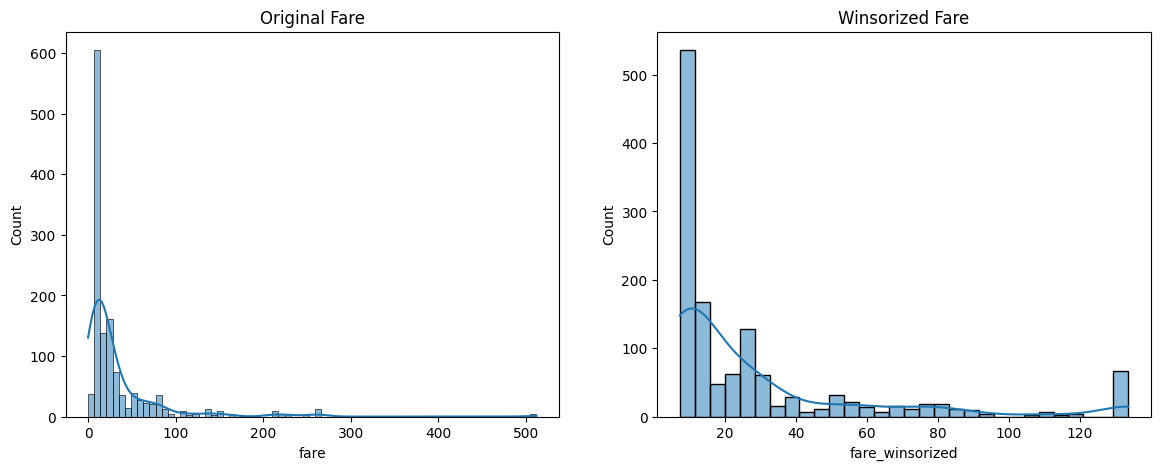

In [15]:
# Winsorization example: cap fare at 5th and 95th percentiles

titanic_winsorized = titanic_clean.copy()

lower_cap = titanic_winsorized["fare"].quantile(0.05)
upper_cap = titanic_winsorized["fare"].quantile(0.95)

titanic_winsorized["fare_winsorized"] = titanic_winsorized["fare"].clip(
    lower=lower_cap,
    upper=upper_cap
)

print("Lower cap:", lower_cap)
print("Upper cap:", upper_cap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(titanic_winsorized["fare"], kde=True, ax=axes[0])
axes[0].set_title("Original Fare")

sns.histplot(titanic_winsorized["fare_winsorized"], kde=True, ax=axes[1])
axes[1].set_title("Winsorized Fare")

plt.show()

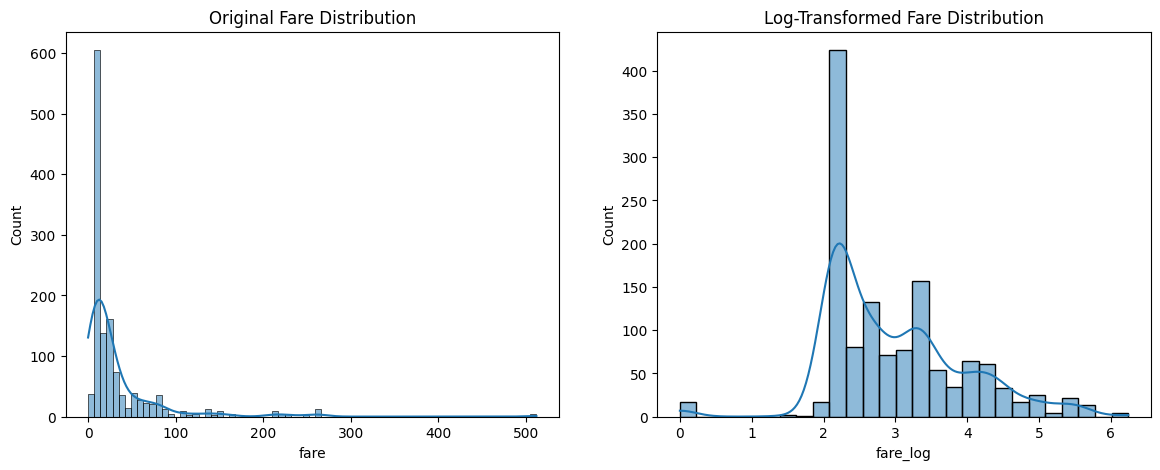

In [16]:
# Log transformation for skewed data

titanic_winsorized["fare_log"] = np.log1p(titanic_winsorized["fare"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(titanic_winsorized["fare"], kde=True, ax=axes[0])
axes[0].set_title("Original Fare Distribution")

sns.histplot(titanic_winsorized["fare_log"], kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Fare Distribution")

plt.show()

### Scaling

Scaling is important when feature magnitudes differ.

It is especially important for:

- Linear models
- SVM
- KNN
- Neural networks

It is usually less important for tree-based models.

Common scaling methods:

1. **Standardization**
   - Mean = 0
   - Standard deviation = 1

2. **Normalization**
   - Values between 0 and 1

3. **Robust scaling**
   - Uses median and IQR
   - Better when outliers are present

In [17]:
# Prepare numeric data for scaling

scale_cols = ["age", "fare", "sibsp", "parch"]

scaling_df = titanic_clean[scale_cols].copy()

display(scaling_df.describe())

,age,fare,sibsp,parch
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,29.503183,33.281086,0.498854,0.385027
std,12.905246,51.741500,1.041658,0.865560
min,0.166700,0.000000,0.000000,0.000000
25%,22.000000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,9.000000


In [18]:
# Apply different scalers

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(scaling_df),
    columns=[col + "_standard" for col in scale_cols]
)

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(scaling_df),
    columns=[col + "_minmax" for col in scale_cols]
)

robust_scaled = pd.DataFrame(
    robust_scaler.fit_transform(scaling_df),
    columns=[col + "_robust" for col in scale_cols]
)

scaled_comparison = pd.concat(
    [scaling_df.reset_index(drop=True), standard_scaled, minmax_scaled, robust_scaled],
    axis=1
)

display(scaled_comparison.head())

,age,fare,sibsp,parch,age_standard,fare_standard,sibsp_standard,parch_standard,age_minmax,fare_minmax,sibsp_minmax,parch_minmax,age_robust,fare_robust,sibsp_robust,parch_robust
0,29.0000,211.3375,0.0,0.0,-0.039005,3.442584,-0.479087,-0.445000,0.361169,0.412503,0.000,0.000000,0.076923,8.421302,0.0,0.0
1,0.9167,151.5500,1.0,2.0,-2.215952,2.286639,0.481288,1.866526,0.009395,0.295806,0.125,0.222222,-2.083331,5.864007,1.0,2.0
2,2.0000,151.5500,1.0,2.0,-2.131977,2.286639,0.481288,1.866526,0.022964,0.295806,0.125,0.222222,-2.000000,5.864007,1.0,2.0
3,30.0000,151.5500,1.0,2.0,0.038512,2.286639,0.481288,1.866526,0.373695,0.295806,0.125,0.222222,0.153846,5.864007,1.0,2.0
4,25.0000,151.5500,1.0,2.0,-0.349075,2.286639,0.481288,1.866526,0.311064,0.295806,0.125,0.222222,-0.230769,5.864007,1.0,2.0


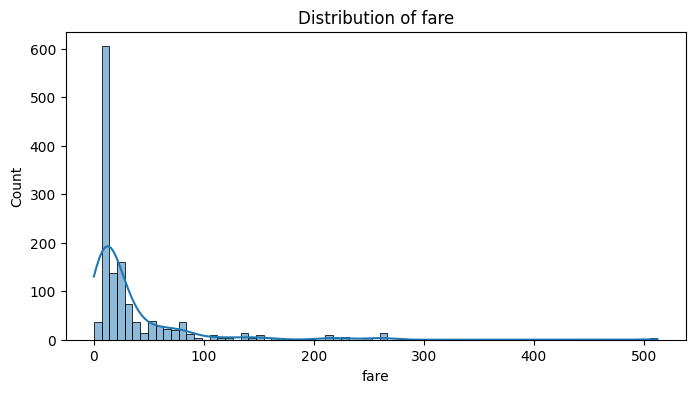

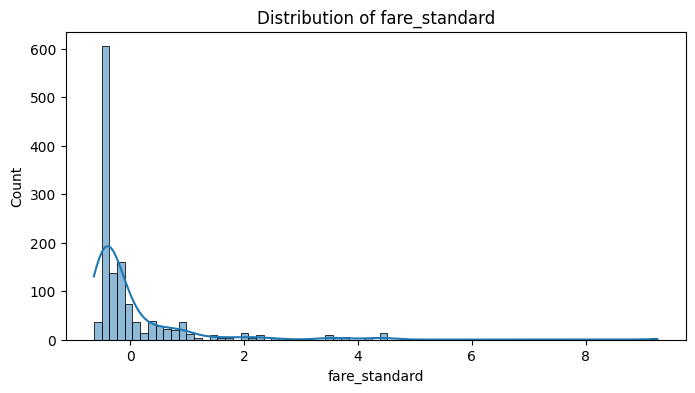

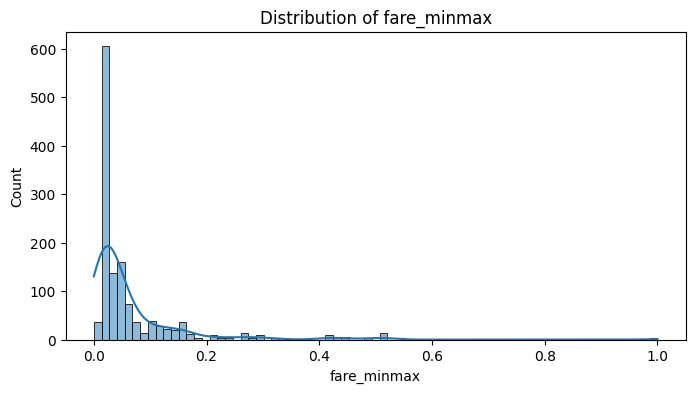

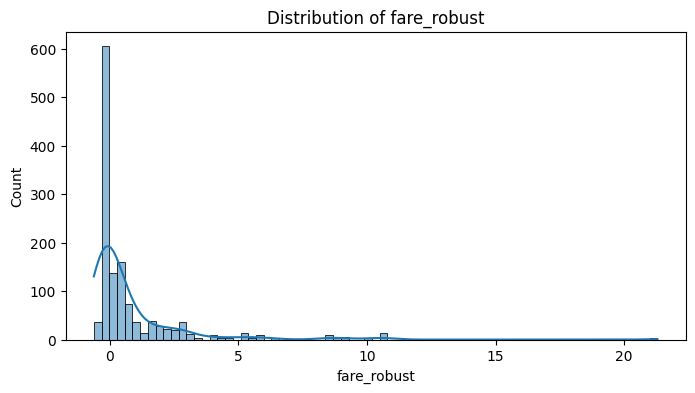

In [19]:
# Compare scaling methods for Fare

comparison_cols = ["fare", "fare_standard", "fare_minmax", "fare_robust"]

for col in comparison_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(scaled_comparison[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [20]:
# Final cleaned Titanic dataset example

final_titanic = titanic_clean.copy()

# Add cleaned/transformed features
final_titanic["fare_winsorized"] = final_titanic["fare"].clip(
    lower=final_titanic["fare"].quantile(0.05),
    upper=final_titanic["fare"].quantile(0.95)
)

final_titanic["fare_log"] = np.log1p(final_titanic["fare"])

# Add scaled numeric features
scaled_features = pd.DataFrame(
    robust_scaler.fit_transform(final_titanic[scale_cols]),
    columns=[col + "_robust_scaled" for col in scale_cols],
    index=final_titanic.index
)

final_titanic = pd.concat([final_titanic, scaled_features], axis=1)

display(final_titanic.head())
print("Final Titanic shape:", final_titanic.shape)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,...,boat,body,home.dest,age_missing,fare_winsorized,fare_log,age_robust_scaled,fare_robust_scaled,sibsp_robust_scaled,parch_robust_scaled
0,1.0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,...,2,155.0,"St Louis, MO",0.0,133.65,5.358177,0.076923,8.421302,0.0,0.0
1,1.0,1,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,...,11,155.0,"Montreal, PQ / Chesterville, ON",0.0,133.65,5.027492,-2.083331,5.864007,1.0,2.0
2,1.0,0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,...,13,155.0,"Montreal, PQ / Chesterville, ON",0.0,133.65,5.027492,-2.000000,5.864007,1.0,2.0
3,1.0,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,...,13,135.0,"Montreal, PQ / Chesterville, ON",0.0,133.65,5.027492,0.153846,5.864007,1.0,2.0
4,1.0,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,...,13,155.0,"Montreal, PQ / Chesterville, ON",0.0,133.65,5.027492,-0.230769,5.864007,1.0,2.0


Final Titanic shape: (1309, 21)


## Key Takeaways

- Always inspect missing values before choosing a strategy.
- Missingness can itself be useful, so missing indicators are often helpful.
- Outliers should be investigated before blindly removing them.
- Use trimming when outliers are errors or extreme noise.
- Use winsorization when you want to reduce extreme influence without deleting rows.
- Use log transformation for highly skewed positive variables.
- Scaling is essential for distance-based and gradient-based models.
- RobustScaler is useful when outliers are present.

## Lending Club Dataset

### Missing Data Detection

We first identify columns with missing values.

Columns with very high missing percentages may be removed, especially if they are not important for modeling. Since this dataset has no missing values, we skip this section.

In [22]:
# Make a working copy

lc = lending_df.copy()

missing_report = pd.DataFrame({
    "missing_count": lc.isnull().sum(),
    "missing_percent": lc.isnull().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_report[missing_report["missing_count"] > 0].head(40))

,missing_count,missing_percent


### Outlier Detection

Loan data often has extreme values in columns like:

- Loan amount
- Annual income
- Interest rate
- Debt-to-income ratio
- Revolving balance

We first find numeric columns with high spread.

In [24]:
# Summary statistics for numeric columns

numeric_cols = lc.select_dtypes(include=[np.number]).columns.tolist()
numeric_summary = lc[numeric_cols].describe().T

numeric_summary["range"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]

display(numeric_summary.sort_values("range", ascending=False).head(20))

,count,mean,std,min,25%,50%,75%,max,range,iqr
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06,1.207359e+06,15062.500000
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04,1.746100e+04,2910.000000
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02,9.244700e+02,268.992500
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02,2.150000e+02,55.000000
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02,1.190000e+02,48.300000
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01,3.300000e+01,2.000000
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01,2.996000e+01,10.737500
delinq.2yrs,9578.0,0.163708,0.546215,0.000000,0.000000,0.000000,0.000000,1.300000e+01,1.300000e+01,0.000000
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01,6.980853e+00,0.732879
pub.rec,9578.0,0.062122,0.262126,0.000000,0.000000,0.000000,0.000000,5.000000e+00,5.000000e+00,0.000000


In [26]:
# Choose common numeric columns if they exist

possible_outlier_cols = [
    "loan_amnt",
    "funded_amnt",
    "annual_inc",
    "int_rate",
    "dti",
    "revol_bal",
    "installment"
]

outlier_cols = [col for col in possible_outlier_cols if col in lc.columns]

print("Outlier columns selected:")
print(outlier_cols)

Outlier columns selected:
['dti', 'installment']


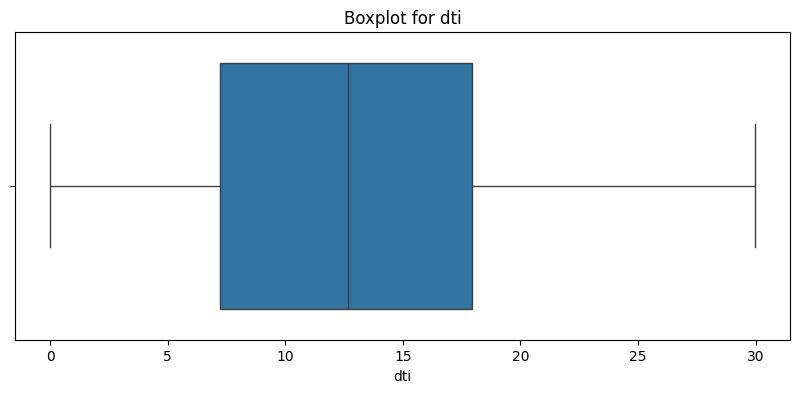

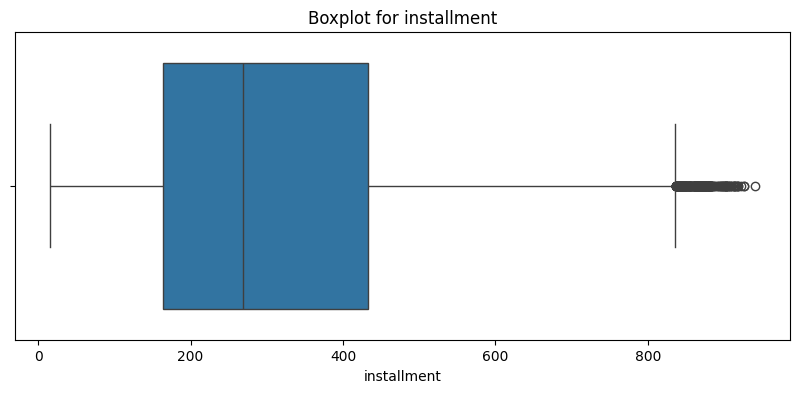

In [27]:
# Boxplots for selected numeric columns

for col in outlier_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=lc[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

### IQR-Based Outlier Detection

The IQR method flags values below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

In [29]:
def iqr_outlier_summary(df, cols):
    rows = []
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_percent = outlier_count / df.shape[0] * 100
        
        rows.append({
            "column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_percent": outlier_percent
        })
    
    return pd.DataFrame(rows).sort_values("outlier_percent", ascending=False)

iqr_summary = iqr_outlier_summary(lc, outlier_cols)
display(iqr_summary)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
1,installment,163.7700,432.7625,268.9925,-239.71875,836.25125,236,2.46398
0,dti,7.2125,17.9500,10.7375,-8.89375,34.05625,0,0.00000


### Winsorization

Instead of removing outliers, we can cap them.

This is useful when extreme values are real but too influential.

In [30]:
lc_winsorized = lc.copy()

for col in outlier_cols:
    lower_cap = lc_winsorized[col].quantile(0.01)
    upper_cap = lc_winsorized[col].quantile(0.99)
    
    lc_winsorized[col + "_winsorized"] = lc_winsorized[col].clip(
        lower=lower_cap,
        upper=upper_cap
    )

print("Winsorized columns created:")
print([col + "_winsorized" for col in outlier_cols])

Winsorized columns created:
['dti_winsorized', 'installment_winsorized']


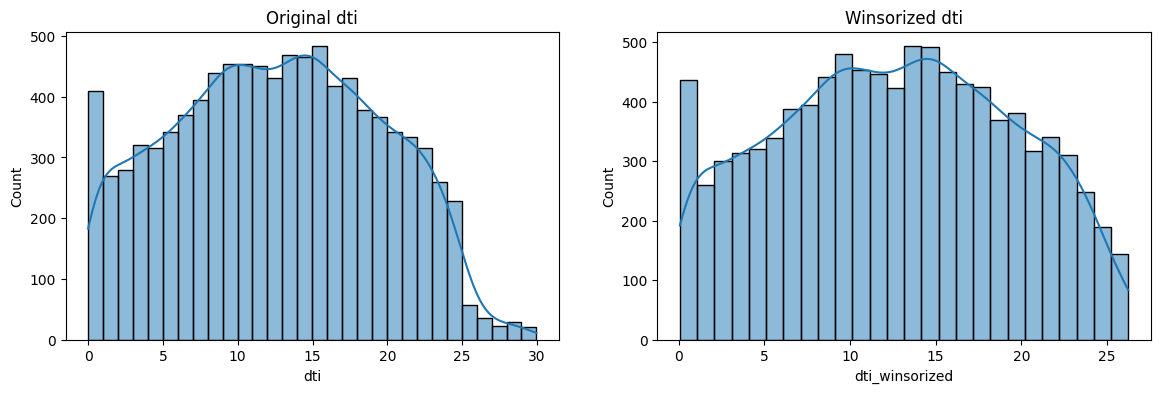

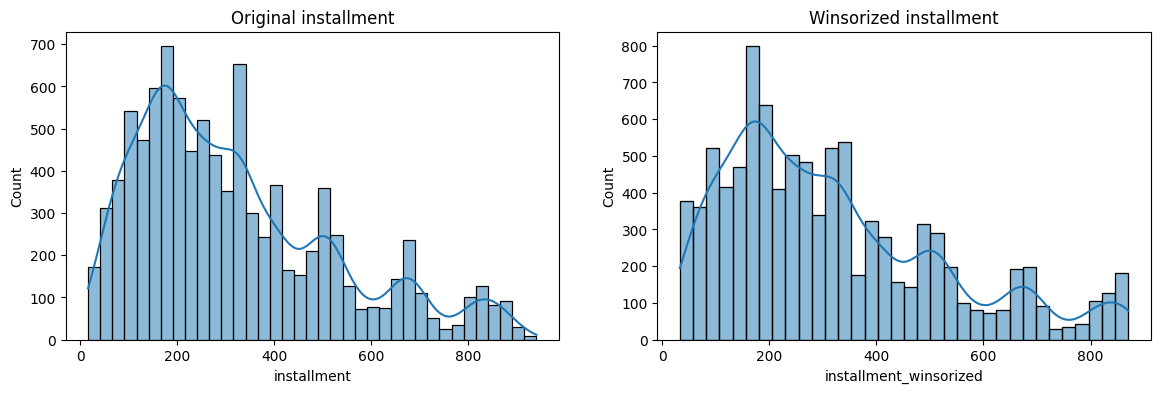

In [31]:
# Compare before and after winsorization

for col in outlier_cols:
    winsor_col = col + "_winsorized"
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.histplot(lc_winsorized[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Original {col}")
    
    sns.histplot(lc_winsorized[winsor_col], kde=True, ax=axes[1])
    axes[1].set_title(f"Winsorized {col}")
    
    plt.show()

### Log Transformation

For highly skewed positive variables, log transformation can make the distribution less extreme.

We use `np.log1p()` because it safely handles zero values.

No columns log transformed

In [34]:
log_transform_candidates = [
    "annual_inc",
    "revol_bal",
    "loan_amnt",
    "funded_amnt"
]

log_cols = [col for col in log_transform_candidates if col in lc.columns]

for col in log_cols:
    lc[col + "_log"] = np.log1p(lc[col])

print("Log-transformed columns created:")
print([col + "_log" for col in log_cols])

Log-transformed columns created:
[]


### Isolation Forest for Multivariate Outliers

Isolation Forest detects unusual rows based on multiple variables together.

This is more advanced than checking one column at a time.

In [35]:
iso_cols = outlier_cols.copy()

iso_data = lc_winsorized[iso_cols].copy()

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

lc_winsorized["isolation_forest_flag"] = iso_model.fit_predict(iso_data)

# -1 means outlier, 1 means normal
lc_winsorized["is_multivariate_outlier"] = lc_winsorized["isolation_forest_flag"] == -1

display(lc_winsorized["is_multivariate_outlier"].value_counts())

is_multivariate_outlier
False    9099
True      479
Name: count, dtype: int64

In [37]:
# Scatter plot if useful columns exist

if "annual_inc" in lc_winsorized.columns and "loan_amnt" in lc_winsorized.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=lc_winsorized.sample(min(5000, lc_winsorized.shape[0]), random_state=42),
        x="annual_inc",
        y="loan_amnt",
        hue="is_multivariate_outlier",
        alpha=0.6
    )
    plt.title("Multivariate Outliers: Annual Income vs Loan Amount")
    plt.show()

### Scaling

Scaling is important for:

- Logistic regression
- Linear regression
- SVM
- KNN
- Neural networks

Tree-based models usually do not require scaling.

We compare:

1. StandardScaler  
2. MinMaxScaler  
3. RobustScaler  

In [38]:
scaling_cols = outlier_cols.copy()

scaling_data = lc_winsorized[scaling_cols].copy()

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(scaling_data),
    columns=[col + "_standard_scaled" for col in scaling_cols],
    index=lc_winsorized.index
)

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(scaling_data),
    columns=[col + "_minmax_scaled" for col in scaling_cols],
    index=lc_winsorized.index
)

robust_scaled = pd.DataFrame(
    robust_scaler.fit_transform(scaling_data),
    columns=[col + "_robust_scaled" for col in scaling_cols],
    index=lc_winsorized.index
)

display(standard_scaled.head())
display(minmax_scaled.head())
display(robust_scaled.head())

,dti_standard_scaled,installment_standard_scaled
0,0.998505,2.463099
1,0.244540,-0.438854
2,-0.141885,0.230708
3,-0.654697,-0.757022
4,0.343326,-1.043992


,dti_minmax_scaled,installment_minmax_scaled
0,0.650200,0.879888
1,0.476969,0.229916
2,0.388184,0.379883
3,0.270360,0.158653
4,0.499666,0.094378


,dti_robust_scaled,installment_robust_scaled
0,0.634692,2.082400
1,0.151339,-0.151417
2,-0.096391,0.363988
3,-0.425146,-0.396331
4,0.214668,-0.617229


In [39]:
# Add robust scaled features to final dataset

lc_final = pd.concat(
    [lc_winsorized, robust_scaled],
    axis=1
)

print("Final cleaned LendingClub shape:", lc_final.shape)
display(lc_final.head())

Final cleaned LendingClub shape: (9578, 20)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,dti_winsorized,installment_winsorized,isolation_forest_flag,is_multivariate_outlier,dti_robust_scaled,installment_robust_scaled
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,19.48,829.10,1,False,0.634692,2.082400
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,14.29,228.22,1,False,0.151339,-0.151417
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,11.63,366.86,1,False,-0.096391,0.363988
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,8.10,162.34,1,False,-0.425146,-0.396331
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,14.97,102.92,1,False,0.214668,-0.617229


### Final Data Cleaning Summary

In this section, we:

- Checked duplicate rows
- Measured missing values
- Dropped columns with very high missingness
- Added missing indicators
- Imputed numeric and categorical columns
- Detected outliers using boxplots and IQR
- Applied winsorization
- Applied log transformation for skewed variables
- Detected multivariate outliers using Isolation Forest
- Created scaled features using RobustScaler

For LendingClub-style financial data, median imputation, winsorization, log transformation, and robust scaling are often safer than mean imputation and standard scaling because financial data is usually skewed and contains large outliers.